<a href="https://colab.research.google.com/github/timberking2/ML_magistr/blob/main/Lab2_linguistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
!pip install spacy pymorphy3
!python -m spacy download ru_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 54.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Импортим всё что нужно (не стал использовать наташу т.к. есть опыт работы с spacy + как по мне результат может быть лучше, хоть и душки больше )

In [46]:
import json, sqlite3
from collections import Counter
import pandas as pd
import spacy

nlp = spacy.load("ru_core_news_sm")

# Попробуем pymorphy3 для лемматизации (если нет – используем .lemma_ от spaCy)
try:
    import pymorphy3
    morph = pymorphy3.MorphAnalyzer()
    def lemmatize_word(word):
        return morph.parse(word)[0].normal_form
except ImportError:
    def lemmatize_word(word):
        # fallback – spaCy (будет не совсем точным для отдельных слов, но ок)
        return nlp(word)[0].lemma_ if nlp(word) else word

In [47]:
# Читаем новости из JSON
with open('data_news.json', 'r', encoding='utf-8') as f:
    news = json.load(f)

# Читаем статьи из БД (если есть)
articles = []
try:
    conn = sqlite3.connect('articles.db')
    cur = conn.cursor()
    cur.execute("SELECT title, body FROM articles")
    for row in cur.fetchall():
        articles.append({'title': row[0], 'text': row[1]})
    conn.close()
except:
    pass

# Приводим всё к единому формату
rows = []
for item in news:
    rows.append({'title': item.get('title', ''), 'body': item.get('text', '')})
for item in articles:
    rows.append({'title': item.get('title', ''), 'body': item.get('text', '')})

df = pd.DataFrame(rows)
print(f"Всего новостей/статей: {len(df)}")

Всего новостей/статей: 552


In [56]:
THEME_DICTIONARY = {
    "Релизы игр": [
        "ранний доступ", "ушла на золото", "анонс", "трейлер", "тизер",
        "выход", "выйдет", "релиз", "запуск", "премьера", "дебют"
    ],
    "Платформы / Железо": [
        "процессор", "видеокарта", "чип", "железо", "материнская плата",
        "ноутбук", "монитор", "клавиатура", "мышь", "гарнитура", "накопитель",
        "консоль", "портативная", "смартфон", "пк"
    ],
    "Компании": [
        "компания", "издатель", "студия", "корпорация", "разработчик",
        "холдинг", "стартап", "бренд", "производитель"
    ],
    "Личности": [
        "директор", "президент", "основатель", "блогер", "журналист",
        "геймдизайнер", "сценарист", "продюсер", "инженер", "программист",
        "аналитик", "эксперт",
        "Штраус Зельник", "Джейсон Шрайер", "Крис Авеллон",
        "Даниель Вавра", "Хидео Кодзима", "Тодд Говард"
    ],
    "Софт и технологии": [
        "операционная система", "браузер", "приложение", "утилита",
        "драйвер", "прошивка", "алгоритм", "искусственный интеллект",
        "машинное обучение", "облачные вычисления", "блокчейн", "криптовалюта"
    ]
}

def classify_article(body_text):
    text_lower = str(body_text).lower()
    matches = {}
    for theme, keywords in THEME_DICTIONARY.items():
        score = sum(1 for kw in keywords if kw.lower() in text_lower)
        matches[theme] = score
    best = max(matches, key=matches.get)
    return best if matches[best] > 0 else "Прочее"

df["theme"] = df["body"].apply(classify_article)

# проверим
print("Пример разметки:")
print(df[["title", "theme"]].head())

Пример разметки:
                                               title       theme
0  Патч 1.0.4.0 для Escape from Tarkov: соло-Scav...    Компании
1  Как повысить FPS в Resident Evil Requiem на 70...    Компании
2  Российским игровым студиям предоставили льготы...    Компании
3                 Когда разблокируют Roblox в России    Компании
4  Релиз Crimson Desert: успех в Steam и смешанны...  Релизы игр


In [54]:
def extract_all_subject_verb_pairs(text):
    """
    Возвращает список кортежей (лемма_субъекта, лемма_глагола)
    для всех связей подлежащее-сказуемое в тексте.
    """
    doc = nlp(text)
    pairs = []
    for token in doc:
        if token.pos_ != "VERB":
            continue
        verb_lemma = token.lemma_
        for child in token.children:
            if child.dep_ in ("nsubj", "nsubj:pass"):
                # Собираем поддерево субъекта (как в коде друга)
                subj_words = [w.text for w in child.subtree if w.pos_ in ("NOUN", "PROPN", "ADJ")]
                if not subj_words:
                    # Если подлежащее – местоимение, пропускаем
                    continue
                # Лемматизируем каждое слово и соединяем
                subj_lemmas = [lemmatize_word(w) for w in subj_words]
                subj_lemma = " ".join(subj_lemmas).lower()
                pairs.append((subj_lemma, verb_lemma))
                break   # один субъект на глагол
    return pairs

# Извлекаем пары из всех текстов
all_pairs = []
for idx, row in df.iterrows():
    pairs = extract_all_subject_verb_pairs(str(row["body"]))
    all_pairs.extend(pairs)

# Подсчитываем частоты
pair_counter = Counter(all_pairs)
print(f"Всего извлечено пар: {len(all_pairs)}")

Всего извлечено пар: 50334


In [58]:
print("=== Топ-40 действий (субъект → глагол) ===")
for (subj, verb), count in pair_counter.most_common(40):
    print(f"{subj} → {verb}: {count}")

# Сохраняем в JSON
result = {
    "themes": df["theme"].value_counts().to_dict(),
    "top_pairs": [{"subject": s, "verb": v, "count": c} for (s, v), c in pair_counter.most_common(100)]
}

with open('analysis_result.json', 'w', encoding='utf-8') as f:
    json.dump(result, f, ensure_ascii=False, indent=2)
print("\n Результат сохранён в analysis_result.json")

=== Топ-40 действий (субъект → глагол) ===
игрок → мочь: 132
игра → стать: 97
игра → выйти: 97
речь → идти: 69
разработчик → добавить: 56
конфигуратор → рассчитает: 56
игра → мочь: 49
игра → работать: 48
автор → добавить: 48
игра → предлагать: 45
игра → получить: 44
игра → выглядеть: 43
действие → разворачиваться: 41
время → нет: 40
игрок → управлять: 40
игра → получиться: 37
автор → предлагать: 37
нюанс → быть: 33
студия → выпустить: 32
разработчик → решить: 31
игрок → получать: 31
герой → мочь: 31
разработчик → использовать: 30
тоям → вспоминать: 30
событие → разворачиваться: 29
разработчик → выпустить: 28
персонаж → мочь: 28
сюжет → рассказывать: 28
игрок → видеть: 27
пользователь → мочь: 26
игрок → смочь: 26
игра → требовать: 26
успех → зависеть: 26
год → пройти: 25
разработчик → обещать: 23
игра → использовать: 21
разработчик → планировать: 21
разработчик → делать: 21
игра → поддерживать: 21
последний → мочь: 21

 Результат сохранён в analysis_result.json


Можно вывести графики


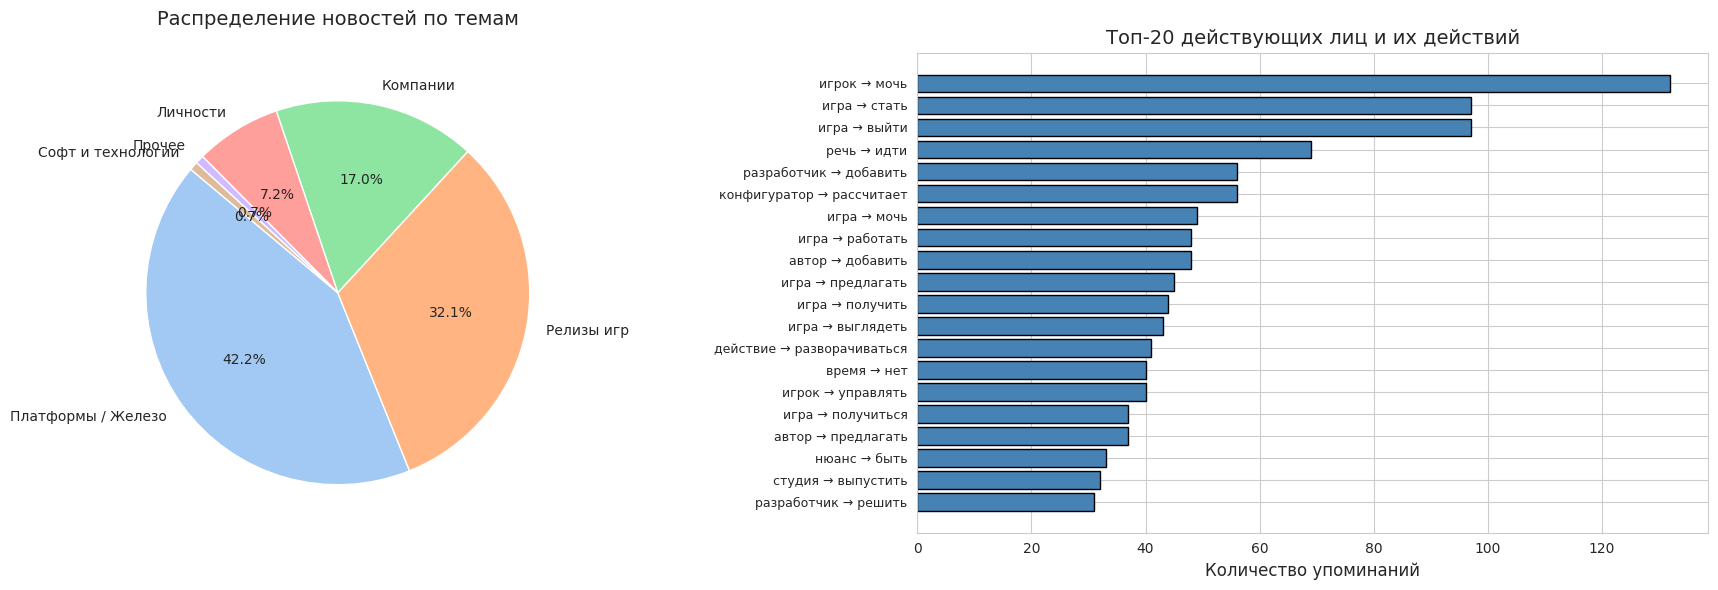

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# график распределения тем
theme_counts = df["theme"].value_counts()
colors = sns.color_palette("pastel", len(theme_counts))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# круговая диаграмма
axes[0].pie(theme_counts.values, labels=theme_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors, textprops={'fontsize': 10})
axes[0].set_title('Распределение новостей по темам', fontsize=14, pad=20)

# топ-20 действий
top_pairs = pair_counter.most_common(20)
labels = [f"{subj} → {verb}" for (subj, verb), _ in top_pairs]
values = [count for _, count in top_pairs]

# горизонтальный barplot
y_pos = np.arange(len(labels))
axes[1].barh(y_pos, values, color='steelblue', edgecolor='black')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(labels, fontsize=9)
axes[1].invert_yaxis()  # самая частая сверху
axes[1].set_xlabel('Количество упоминаний', fontsize=12)
axes[1].set_title('Топ-20 действующих лиц и их действий', fontsize=14)

plt.tight_layout()
plt.show()